In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\Padka\.AAPort\insurance.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df[df.duplicated(keep=False)]

In [63]:
df = df.drop_duplicates()

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

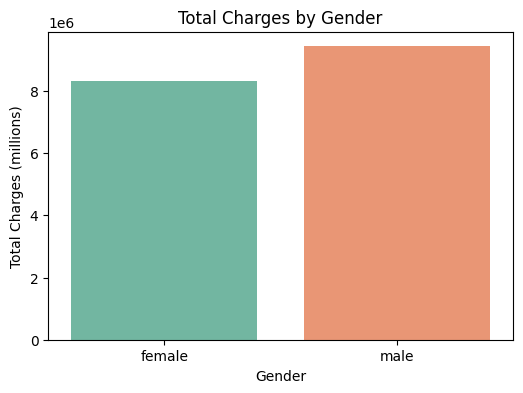

In [11]:
revenue_gender = df.groupby('sex')['charges'].sum(numeric_only=True).reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='charges', data=revenue_gender, hue='sex', palette='Set2')
plt.title('Total Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Charges (millions)') 
plt.show()

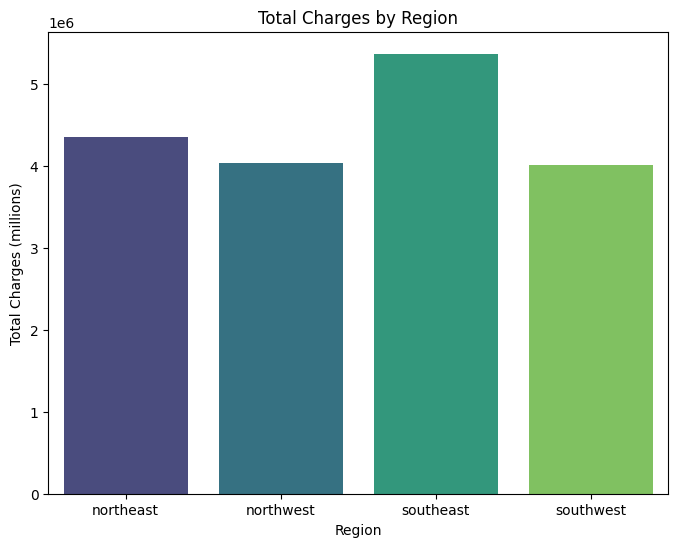

In [44]:
revenue_region = df.groupby('region')['charges'].sum(numeric_only=True).reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(x='region', y='charges', data=revenue_region, hue='region', palette='viridis')
plt.title('Total Charges by Region')
plt.xlabel('Region')
plt.ylabel('Total Charges (millions)')
plt.show()

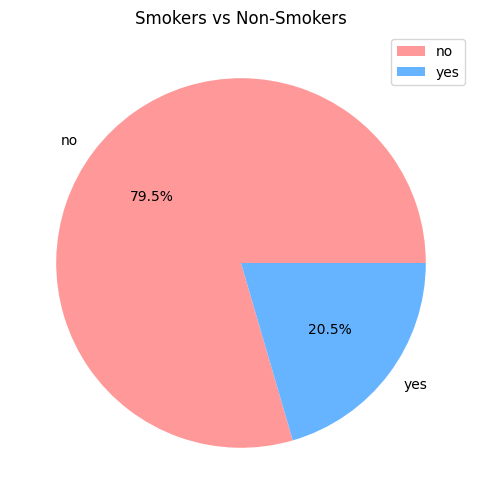

In [5]:
smoker_count = df['smoker'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(smoker_count, labels=smoker_count.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Smokers vs Non-Smokers')
plt.legend(smoker_count.index, loc='upper right')
plt.show()  

Text(0, 0.5, 'Count')

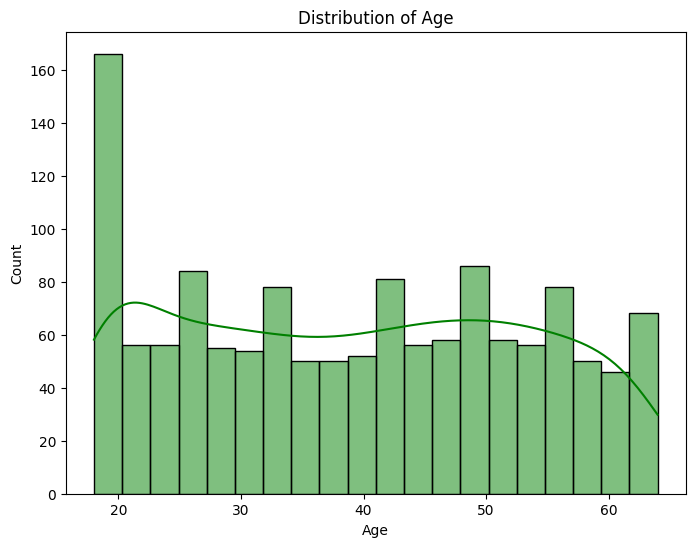

In [52]:
plt.figure(figsize=(8, 6))
sns.histplot(x='age', data=df, bins=20,color='green', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

In [ ]:
df.corr(numeric_only=True)

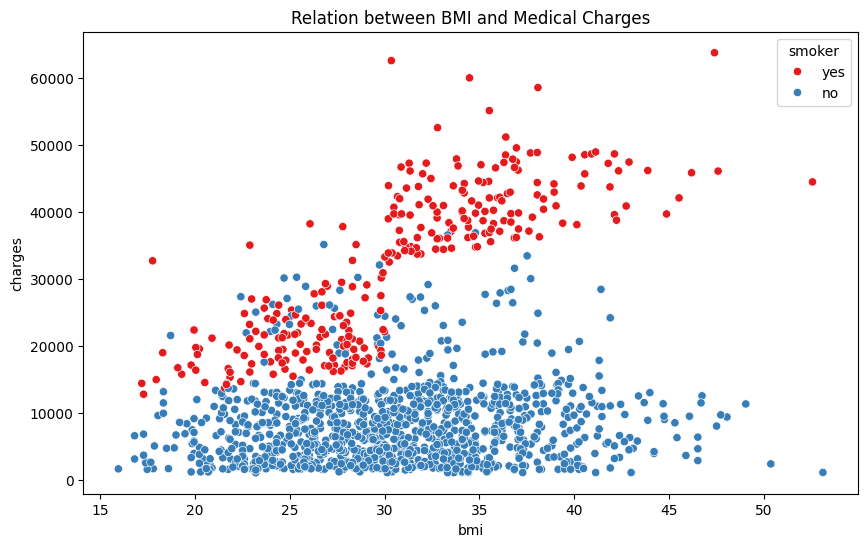

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="bmi",y="charges",hue="smoker",palette="Set1")
plt.title("Relation between BMI and Medical Charges")
plt.show()

In [ ]:
df.head(10)

In [ ]:
from sqlalchemy import create_engine
username = "postgres"          
password = "Ungpao18290" 
host = "localhost"             
port = "5432"                  
database = "Medical-Costs-Analysis"  

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Load DataFrame into PostgreSQL
table_name = "medical_costs"   
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")